In [14]:
import os
import pandas as pd
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rc_context

In [15]:
sc.set_figure_params(vector_friendly=True, dpi_save=600) 

In [16]:
dir_ = '/home/wu/datb1/AutoExtractSingleCell/01.benchmark_datasets/prompts_variants/'
os.chdir(dir_)

df = pd.read_csv('deepseek_v3/preprocess_resp/prompts_variant_preprocess_deepseek.csv')
df['Sample'] = df['Sample'].str.replace('_', ' ').replace('original response', 'Original Response')
df['Rep'] = df['Rep'].astype(int)
order = ['Original Response', 'Instruction Reordering', 'Minimalistic Annotation', 'Terminology Modification', 'Enhanced Guidance', 'Structural Reformatting']
df = df.sort_values(
    by=['Sample', 'Rep'],
    key=lambda col: col.map({idx: i for i, idx in enumerate(order)}) if col.name == 'Sample' else col,
    ascending=[True, True],
    inplace=False
)

df.set_index('Sample', inplace=True)

In [17]:
def save_table(df, filename, title):
    from reportlab.lib import colors
    from reportlab.lib.pagesizes import letter, landscape
    from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import inch
    import pandas as pd

    table_data = [['Experiment'] + df.columns.tolist()]

    for idx, row in df.iterrows():
        table_data.append([idx] + row.tolist())

    pagesize = (landscape(letter)[0]*2.2, landscape(letter)[1])
    doc = SimpleDocTemplate(filename, pagesize=pagesize)
    elements = []

    col_widths = [2.5*inch] + [inch]*2 + [1.85*inch] * (len(df.columns)-2)

    table = Table(table_data, colWidths=col_widths)

    styles = getSampleStyleSheet()
    title_style = ParagraphStyle(
        name='TableTitle',
        parent=styles['Heading2'],
        alignment=1,
        spaceAfter=12
    )

    table_name = Paragraph(title, title_style)
    elements.append(table_name)
    elements.append(Spacer(1, 0.1*inch)) 

    table.setStyle(TableStyle([
        ('FONT', (0, 0), (-1, -1), 'Helvetica', 10),
        ('FONT', (0, 0), (-1, 0), 'Helvetica-Bold', 10),
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('BACKGROUND', (0, 1), (0, -1), colors.lightgrey),
        ('FONT', (0, 1), (0, -1), 'Helvetica-Bold', 10),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('GRID', (0, 0), (-1, -1), 1, colors.black),
        ('VALIGN', (0, 0), (-1, -1), 'MIDDLE'),
        ('RIGHTPADDING', (0, 0), (-1, -1), 10),
        ('LEFTPADDING', (0, 0), (-1, -1), 10),
    ]))

    elements.append(table)

    doc.build(elements)

In [18]:
save_table(df,
        '/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/prompt_variation/' + 'preprocess_resp_table_deepseek.pdf',
        'Parameters Table of DeepSeek Using Different Prompt Variants (DeepSeek v3)')

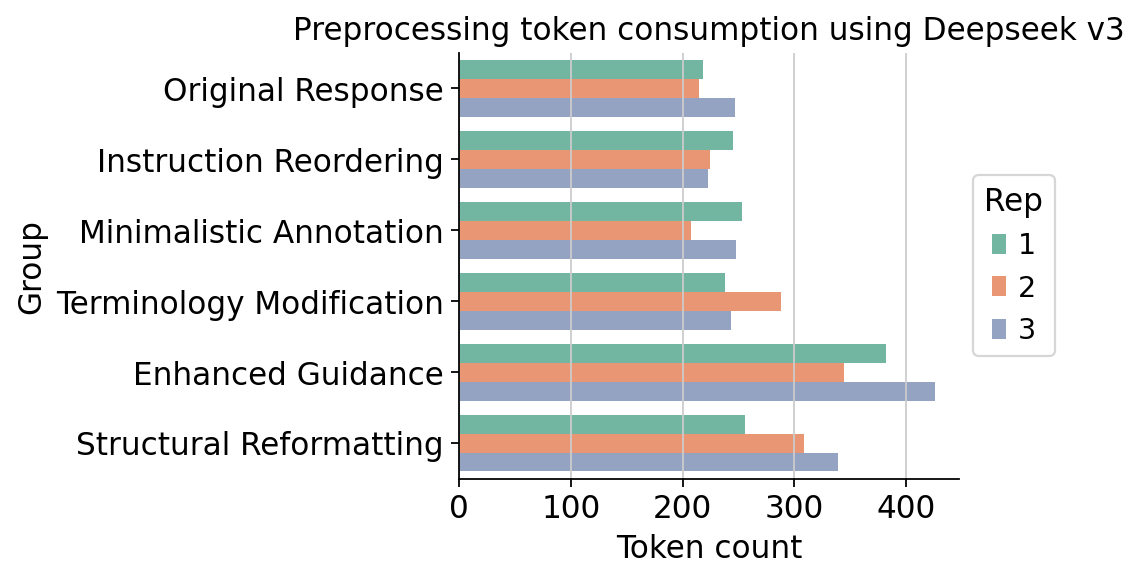

In [19]:
with rc_context({'figure.figsize': (4, 3.5)}):
    g = sns.barplot(data=df, x='token_count', y='Sample', hue='Rep', palette='Set2', order=order)
    sns.despine()
    # move the legend to the right
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Rep')
    g.set(xlabel='Token count', ylabel='Group')
    g.xaxis.set_ticks_position('bottom')
    g.set_title('Preprocessing token consumption using Deepseek v3')
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/prompt_variation/preprocess_resp_token_count_deepseek.pdf', bbox_inches='tight')

In [10]:
dir_ = '/home/wu/datb1/AutoExtractSingleCell/01.benchmark_datasets/prompts_variants/'
os.chdir(dir_)

df = pd.read_csv('preprocess_resp/prompts_variant_preprocess.csv')
df['Sample'] = df['Sample'].str.replace('_', ' ').replace('original response', 'Original Response')
df['Rep'] = df['Rep'].astype(int)
order = ['Original Response', 'Instruction Reordering', 'Minimalistic Annotation', 'Terminology Modification', 'Enhanced Guidance', 'Structural Reformatting']
df = df.sort_values(
    by=['Sample', 'Rep'],
    key=lambda col: col.map({idx: i for i, idx in enumerate(order)}) if col.name == 'Sample' else col,
    ascending=[True, True],
    inplace=False
)

df.set_index('Sample', inplace=True)

save_table(df,
        '/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/prompt_variation/' + 'preprocess_resp_table.pdf',
        'Parameters Table of DeepSeek Using Different Prompt Variants (Claude 3.5 sonnet)')

In [11]:
# sns.set(style='white')

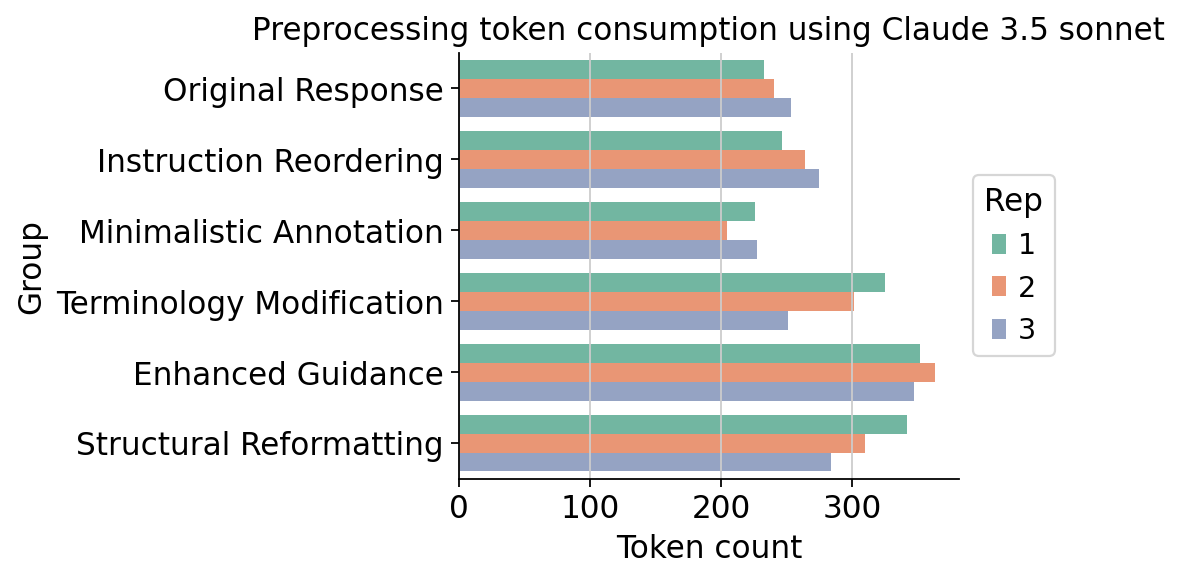

In [13]:
with rc_context({'figure.figsize': (4, 3.5)}):
    g = sns.barplot(data=df, x='token_count', y='Sample', hue='Rep', palette='Set2', order=order)
    sns.despine()
    # move the legend to the right
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Rep')
    g.set(xlabel='Token count', ylabel='Group')
    g.xaxis.set_ticks_position('bottom')
    g.set_title('Preprocessing token consumption using Claude 3.5 sonnet')
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/prompt_variation/preprocess_resp_token_count.pdf', bbox_inches='tight')

### Cell Annotation

In [ ]:
order_anno = []
for x in order:
    for i in range(1, 4):
        order_anno.append(x + ' ' + str(i))

In [75]:
df = pd.read_csv('annotation_resp/prompts_variant_cell_annotations.csv')
df['Sample'] = df['Sample'].str.replace('_', ' ').replace('original response', 'Original Response')
order = ['Original Response', 'Instruction Reordering', 'Minimalistic Annotation', 'Terminology Modification', 'Enhanced Guidance', 'Structural Reformatting']
df.sort_values(['Sample', 'Rep'], inplace=True)
df.set_index('Sample', inplace=True)
df['Sample_Rep'] = df.index + ' ' + df['Rep'].astype(str)
df = df.pivot_table(index='cluster', columns='Sample_Rep', values='cell_type', aggfunc='sum', fill_value='')
df = df.T.sort_index(key=lambda x: x.map(order_anno.index))
df

cluster,0,1,2,3,4,5,6,7,8,9,10,11,12
Sample_Rep,,,,,,,,,,,,,
Original Response 1,PDGFRA+ fibroblast,MKX+ fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Vascular endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Nerve cell,T cell
Original Response 2,PDGFRA+ fibroblast,MKX+ fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Vascular endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Nerve cell,T cell
Original Response 3,PDGFRA+ fibroblast,MKX+ fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Vascular endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Nerve cell,T cell
Instruction Reordering 1,PDGFRA+ fibroblast,MKX+ fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Vascular endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Nerve cell,T cell
Instruction Reordering 2,PDGFRA+ fibroblast,MKX+ fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Vascular endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Nerve cell,T cell
Instruction Reordering 3,PDGFRA+ fibroblast,MKX+ fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Vascular endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Nerve cell,T cell
Minimalistic Annotation 1,PDGFRA+ fibroblast,MKX+ fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Vascular endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Nerve cell,T cell
Minimalistic Annotation 2,PDGFRA+ fibroblast,MKX+ fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Vascular endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Nerve cell,T cell
Minimalistic Annotation 3,PDGFRA+ fibroblast,MKX+ fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Vascular endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Nerve cell,T cell


In [76]:
def save_annotation_table(df, filename, title):
    from reportlab.lib import colors
    from reportlab.lib.pagesizes import letter, landscape
    from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import inch
    import pandas as pd

    table_data = [['Experiment'] + df.columns.tolist()]

    for idx, row in df.iterrows():
        table_data.append([idx] + row.tolist())

    pagesize = (landscape(letter)[0]*2.2, landscape(letter)[1])
    doc = SimpleDocTemplate(filename, pagesize=pagesize)
    elements = []

    col_widths = [2.5*inch] + [2.2*inch] * (len(df.columns))

    table = Table(table_data, colWidths=col_widths)

    styles = getSampleStyleSheet()
    title_style = ParagraphStyle(
        name='TableTitle',
        parent=styles['Heading2'],
        alignment=1,
        spaceAfter=12
    )

    table_name = Paragraph(title, title_style)
    elements.append(table_name)
    elements.append(Spacer(1, 0.1*inch)) 

    table.setStyle(TableStyle([
        ('FONT', (0, 0), (-1, -1), 'Helvetica', 10),
        ('FONT', (0, 0), (-1, 0), 'Helvetica-Bold', 10),
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('BACKGROUND', (0, 1), (0, -1), colors.lightgrey),
        ('FONT', (0, 1), (0, -1), 'Helvetica-Bold', 10),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('GRID', (0, 0), (-1, -1), 1, colors.black),
        ('VALIGN', (0, 0), (-1, -1), 'MIDDLE'),
        ('RIGHTPADDING', (0, 0), (-1, -1), 10),
        ('LEFTPADDING', (0, 0), (-1, -1), 10),
    ]))

    elements.append(table)

    doc.build(elements)

In [77]:
df.to_csv('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/prompt_variation/annotation_resp_table.csv')

In [78]:
save_annotation_table(df.iloc[:, :5], '/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/prompt_variation/annotation_resp_table.pdf', 
           'Cell Annotations Table of DeepSeek Using Different Prompt Variants (Claude 3.5 sonnet) Part I')

In [63]:
df = pd.read_csv('deepseek_v3/annotation_resp/prompts_variant_cell_annotations_deepseek.csv')
df['Sample'] = df['Sample'].str.replace('_', ' ').replace('original response', 'Original Response')
order = ['Original Response', 'Instruction Reordering', 'Minimalistic Annotation', 'Terminology Modification', 'Enhanced Guidance', 'Structural Reformatting']
df.sort_values(['Sample', 'Rep'], inplace=True)
df.set_index('Sample', inplace=True)
df['Sample_Rep'] = df.index + ' ' + df['Rep'].astype(str)
df = df.pivot_table(index='cluster', columns='Sample_Rep', values='cell_type', aggfunc='sum', fill_value='')
df = df.T.sort_index(key=lambda x: x.map(order_anno.index))
df

cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13
Sample_Rep,,,,,,,,,,,,,,
Original Response 1,PDGFRA+ fibroblasts,MKX+ fibroblasts,Fast-twitch skeletal muscle cells,Transitional skeletal muscle cells,Slow-twitch skeletal muscle cells,Vascular endothelial cells,Satellite cells,Mural cells,Lymphatic endothelial cells,Adipocytes,Macrophages,T cells,Nerve cells,Dendritic cells
Original Response 2,PDGFRA+ fibroblast,MKX+ fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Vascular endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Dendritic cell,Nerve cell,T cell
Original Response 3,PDGFRA+ fibroblasts,MKX+ fibroblasts,Fast-twitch skeletal muscle cells,Transitional skeletal muscle cells,Slow-twitch skeletal muscle cells,Vascular endothelial cells,Satellite cells,Mural cells,Lymphatic endothelial cells,Adipocytes,Macrophages,Dendritic cells,Nerve cells,T cells
Instruction Reordering 1,PDGFRA+ fibroblasts,MKX+ fibroblasts,Fast-twitch skeletal muscle cells,Transitional skeletal muscle cells,Slow-twitch skeletal muscle cells,Vascular endothelial cells,Satellite cells,Mural cells,Lymphatic endothelial cells,Adipocytes,Macrophages,Dendritic cells,Nerve cells,T cells
Instruction Reordering 2,PDGFRA+ fibroblasts,MKX+ fibroblasts,Fast-twitch skeletal muscle cells,Transitional skeletal muscle cells,Slow-twitch skeletal muscle cells,Vascular endothelial cells,Satellite cells,Mural cells,Lymphatic endothelial cells,Adipocytes,Macrophages,Dendritic cells,Nerve cells,T cells
Instruction Reordering 3,PDGFRA+ fibroblasts,MKX+ fibroblasts,Fast-twitch skeletal muscle cells,Transitional skeletal muscle cells,Slow-twitch skeletal muscle cells,Vascular endothelial cells,Satellite cells,Mural cells,Lymphatic endothelial cells,Adipocytes,Macrophages,Dendritic cells,Nerve cells,T cells
Minimalistic Annotation 1,Fibroblast,Fibroblast,Skeletal muscle cell (fast-twitch),Skeletal muscle cell (transitional),Skeletal muscle cell (slow-twitch),Endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Dendritic cell,Nerve cell,T cell
Minimalistic Annotation 2,Fibroblast,Fibroblast,Fast-twitch skeletal muscle cell,Transitional skeletal muscle cell,Slow-twitch skeletal muscle cell,Endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Dendritic cell,Nerve cell,T cell
Minimalistic Annotation 3,Fibroblast,Fibroblast,Skeletal muscle cell (fast-twitch),Skeletal muscle cell (transitional),Skeletal muscle cell (slow-twitch),Endothelial cell,Satellite cell,Mural cell,Lymphatic endothelial cell,Adipocyte,Macrophage,Nerve cell,Nerve cell,T cell


In [57]:
save_annotation_table(df.iloc[:, :5], '/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/prompt_variation/annotation_resp_table_deepseek.pdf', 
           'Cell Annotations Table of DeepSeek Using Different Prompt Variants (DeepSeek v3) Part I')

In [64]:
df.to_csv('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/prompt_variation/annotation_resp_table_deepseek.csv')

In [70]:
adata = sc.read_h5ad('clustered_unannotated.h5ad')
df = df.T

from tqdm import tqdm
for col in tqdm(df.columns):
    mapping_dict = dict(zip(range(len(df[col])), df[col]))
    for cluster in range(13):
        adata.obs.loc[:, col] = adata.obs.loc[:, 'louvain'].astype(int).replace(mapping_dict)
    # sc.pl.umap(adata, color=col)
# sc.pl.umap(adata, color='cell_type')

100%|██████████| 18/18 [00:00<00:00, 43.74it/s]


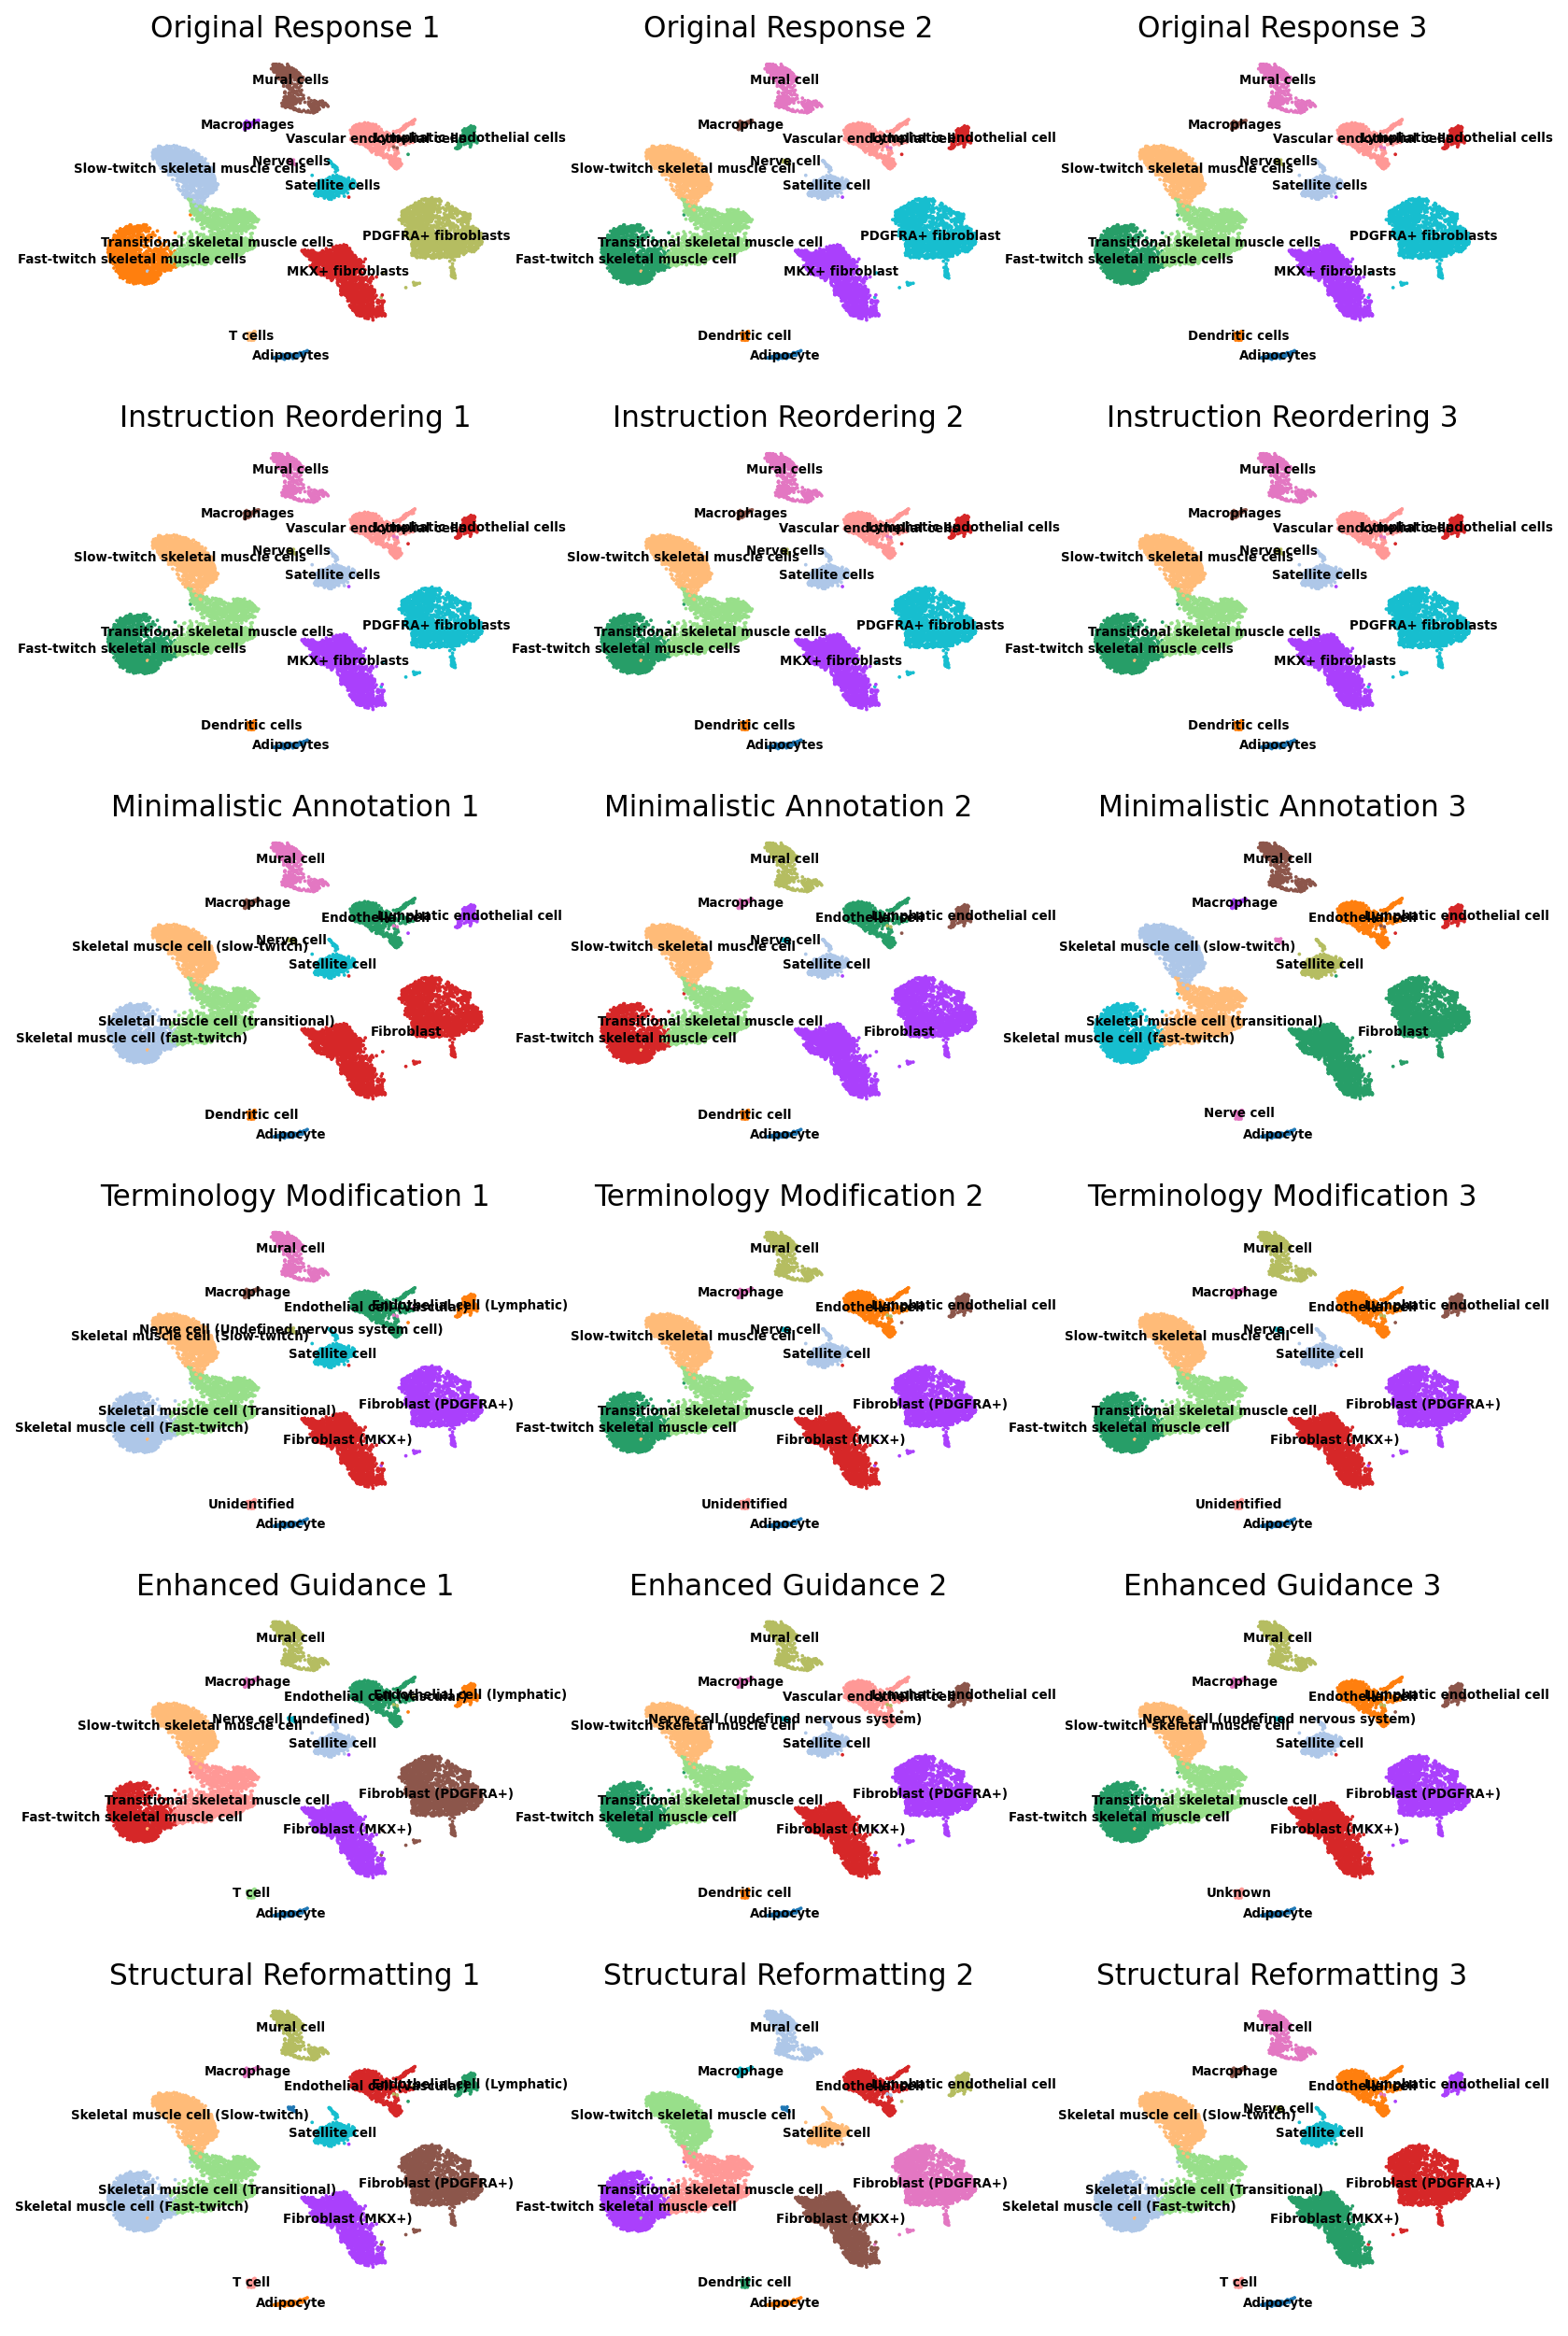

In [74]:
with rc_context({'figure.figsize': (4, 3.5)}):
    fig, axes = plt.subplots(6, 3, figsize=(12, 20))
    for i, col in enumerate(df.columns):
        ax = axes[i//3, i%3]
        g = sc.pl.umap(adata, color=col, show=False, ax=ax, legend_loc='on data', legend_fontsize=6, frameon=False)
